# 🏥 PaliGemma Fine-tuning — Medical VQA

Notebook hỗ trợ:
- ✅ Fine-tune PaliGemma 3B (LoRA) trên SLAKE / PathVQA / VQA-RAD
- ✅ Lưu checkpoint sau mỗi epoch (LoRA weights + processor + optimizer)
- ✅ Resume training từ checkpoint bất kỳ
- ✅ Fine-tune tiếp với dataset khác
- ✅ Load model bất cứ lúc nào để inference / evaluate

```
Luồng:
  [Lần đầu]  → Cell A → Train → lưu checkpoint
  [Resume]   → Cell B → Train tiếp
  [Evaluate] → Phần 7 (chạy độc lập)
  [New data] → Đổi DATASET_NAME + Cell B → Train tiếp
```

In [1]:
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("NLP")
print('✅ Token loaded!')

✅ Token loaded!


In [2]:
import os
os.environ['CUDA_VISIBLE_DEVICES'] = '0' 

## 📦 Phần 1: Cài đặt

In [3]:
!pip install -q transformers datasets accelerate pillow
!pip install -q bitsandbytes peft
print('✅ Done!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 29.8 MB/s eta 0:00:00
✅ Done!


In [4]:
!pip install -q transformers datasets accelerate pillow
!pip install -q bitsandbytes peft
!pip install -q rouge-score sentence-transformers nltk
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print('✅ Done!')

✅ Done!


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [5]:
import torch, os, json, shutil, re
from pathlib import Path
from collections import Counter

print(f'PyTorch : {torch.__version__}')
print(f'CUDA    : {torch.cuda.is_available()}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f'VRAM    : {vram:.1f} GB')
    USE_4BIT = vram < 20
else:
    USE_4BIT = False

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'4-bit   : {USE_4BIT}')

PyTorch : 2.10.0+cu128
CUDA    : True
GPU     : Tesla T4
VRAM    : 15.6 GB
4-bit   : True


## ⚙️ Phần 2: Config — chỉnh tại đây

In [6]:
# ============================================================
#  Copy checkpoint từ Kaggle Models về working dir
#  Chạy cell này trước Phần 3 khi resume
# ============================================================
import shutil, os

src = '/kaggle/input/models/phcminhnmv/paligemma-slake-medical-vqa/transformers/default/1/checkpoints'
dst = '/kaggle/working/checkpoints'

if not os.path.exists(dst):
    shutil.copytree(src, dst)
    print('✅ Copied checkpoints từ Models')
else:
    print('✅ Checkpoints đã có sẵn')

✅ Copied checkpoints từ Models


In [7]:
# ============================================================
#   CONFIG
# ============================================================
DEVICE = 'cuda:0'
# HuggingFace token (bắt buộc)
# 1. Vào https://huggingface.co/google/paligemma-3b-pt-224 → Accept license
# 2. Vào https://huggingface.co/settings/tokens → tạo token
# HF_TOKEN = 'hf_...'  # <- Thay token của bạn
from kaggle_secrets import UserSecretsClient
HF_TOKEN = UserSecretsClient().get_secret("NLP")
# Model
# 'google/paligemma-3b-pt-224'  -> nhẹ nhất, ảnh 224px
# 'google/paligemma-3b-pt-448'  -> tốt hơn cho medical detail
# 'google/paligemma2-3b-pt-224' -> PaliGemma 2 (mới hơn)
BASE_MODEL = 'google/paligemma-3b-pt-224'
IMAGE_SIZE = 224   # phải khớp với model

# LoRA
USE_LORA     = True
LORA_R       = 16
LORA_ALPHA   = 32
LORA_DROPOUT = 0.05
LORA_TARGETS = ['q_proj', 'v_proj', 'k_proj', 'o_proj']

# Checkpoint
CHECKPOINT_DIR = '/kaggle/working/checkpoints'
EXPERIMENT_NAME = 'paligemma_slake'   # đổi khi train dataset khác
SAVE_EVERY_N    = 1                   # lưu sau mỗi N epoch
KEEP_LAST_N     = 3                   # giữ N checkpoint gần nhất

# Dataset
DATASET_NAME = 'mdwiratathya/SLAKE-vqa-english'
# DATASET_NAME = 'flaviagiammarino/path-vqa'
# DATASET_NAME = 'flaviagiammarino/vqa-rad'
TRAIN_SPLIT  = 'train'
TEST_SPLIT   = 'test'

# Hyperparameters
BATCH_SIZE     = 2     # giảm 2 nếu OOM
GRAD_ACCUM     = 8     # effective BS = BATCH_SIZE * GRAD_ACCUM = 16
LEARNING_RATE  = 5e-4  # Giảm LR để tránh overfitting nhanh
NUM_EPOCHS     = 2    # Tăng lên ít nhất 5-10 epoch để model học đủ
MAX_INPUT_LEN  = 256   # giảm từ 512 để tiết kiệm VRAM; câu hỏi medical thường < 256 tokens
MAX_TARGET_LEN = 32
WARMUP_RATIO   = 0.1

# ============================================================
print('✅ Config loaded')
print(f'  Experiment : {EXPERIMENT_NAME}')
print(f'  Base model : {BASE_MODEL}')
print(f'  Dataset    : {DATASET_NAME}')
print(f'  LoRA       : {USE_LORA} (r={LORA_R}, alpha={LORA_ALPHA})')
print(f'  Epochs     : {NUM_EPOCHS} | LR={LEARNING_RATE} | BS={BATCH_SIZE}x{GRAD_ACCUM}')

✅ Config loaded
  Experiment : paligemma_slake
  Base model : google/paligemma-3b-pt-224
  Dataset    : mdwiratathya/SLAKE-vqa-english
  LoRA       : True (r=16, alpha=32)
  Epochs     : 2 | LR=0.0005 | BS=2x8


## 🛠️ Phần 3: Checkpoint Manager

In [8]:
class CheckpointManager:
    """
    Quản lý checkpoint cho PaliGemma.

    Cấu trúc thư mục:
      checkpoints/paligemma_slake/
        checkpoint_epoch1/
          adapter_model/    <- LoRA weights (~50MB)
          processor/        <- tokenizer + image processor
          optimizer.pt
          scheduler.pt
        checkpoint_best/    <- checkpoint có F1 cao nhất
        training_state.json <- metadata để resume
    """
    def __init__(self, base_dir, exp_name):
        self.exp_dir    = Path(base_dir) / exp_name
        self.state_file = self.exp_dir / 'training_state.json'
        self.exp_dir.mkdir(parents=True, exist_ok=True)
        print(f'📁 Checkpoint dir: {self.exp_dir}')

    # ----- SAVE -----
    def save(self, model, processor, epoch, metrics,
             optimizer=None, scheduler=None, use_lora=True, keep_last_n=None):
        ckpt_name = f'checkpoint_epoch{epoch}'
        ckpt_path = self.exp_dir / ckpt_name
        ckpt_path.mkdir(parents=True, exist_ok=True)
        print(f'\n💾 Saving epoch {epoch} -> {ckpt_name}')

        # weights
        if use_lora:
            model.save_pretrained(ckpt_path / 'adapter_model')
            print(f'   adapter_model/ saved (~50MB LoRA weights)')
        else:
            model.save_pretrained(ckpt_path / 'full_model')
            print(f'   full_model/ saved')

        # processor
        processor.save_pretrained(ckpt_path / 'processor')

        # optimizer / scheduler
        if optimizer:
            torch.save(optimizer.state_dict(), ckpt_path / 'optimizer.pt')
        if scheduler:
            torch.save(scheduler.state_dict(), ckpt_path / 'scheduler.pt')

        # training_state.json
        state = self._load_state()
        state.update({
            'last_epoch': epoch,
            'last_checkpoint': ckpt_name,
            'base_model': BASE_MODEL,
            'dataset': DATASET_NAME,
            'use_lora': use_lora,
            'lora_r': LORA_R if use_lora else None,
            'experiment': EXPERIMENT_NAME,
            'hyperparams': {
                'lr': LEARNING_RATE, 'batch_size': BATCH_SIZE,
                'grad_accum': GRAD_ACCUM, 'epochs': NUM_EPOCHS,
                'image_size': IMAGE_SIZE
            }
        })
        if 'history' not in state:
            state['history'] = []
        state['history'].append({'epoch': epoch, 'checkpoint': ckpt_name, **metrics})

        # best checkpoint — tie-break bằng loss (thấp hơn = tốt hơn)
        cur_f1   = metrics.get('val_f1', -1)
        cur_loss = metrics.get('train_loss', float('inf'))
        prev_f1   = state.get('best_f1', -1)
        prev_loss = state.get('best_loss', float('inf'))
        is_better = (cur_f1 > prev_f1) or (cur_f1 == prev_f1 and cur_loss < prev_loss)
        if is_better:
            state['best_f1']   = cur_f1
            state['best_loss'] = cur_loss
            state['best_checkpoint'] = ckpt_name
            best = self.exp_dir / 'checkpoint_best'
            if best.exists():
                shutil.rmtree(best)
            shutil.copytree(ckpt_path, best)
            print(f'   🏆 New best F1={cur_f1:.2f}% loss={cur_loss:.4f} -> checkpoint_best')

        self._save_state(state)
        if keep_last_n:
            self._cleanup(keep_last_n)
        print('   ✅ Done!')
        return ckpt_path

    # ----- LOAD -----
    def load(self, which='last'):
        """
        which: 'last' | 'best' | int (epoch number) | str (checkpoint name)
        Returns: (ckpt_path, state)
        """
        state = self._load_state()
        if not state:
            raise FileNotFoundError('Chua co checkpoint nao! Hay train truoc.')

        if which == 'last':
            name = state.get('last_checkpoint')
        elif which == 'best':
            name = state.get('best_checkpoint', 'checkpoint_best')
        elif isinstance(which, int):
            name = f'checkpoint_epoch{which}'
        else:
            name = which

        path = self.exp_dir / name
        if not path.exists():
            raise FileNotFoundError(f'Khong tim thay: {path}')

        print(f'📂 Loading: {path}')
        return path, state

    # ----- LIST -----
    def list(self):
        state = self._load_state()
        print(f'\n📋 Experiment : {EXPERIMENT_NAME}')
        print(f'   Dir         : {self.exp_dir}')
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        best = self.exp_dir / 'checkpoint_best'
        if not ckpts and not best.exists():
            print('   (Chua co checkpoint nao)')
            return
        history = {h['epoch']: h for h in state.get('history', [])}
        for c in ckpts:
            ep  = int(c.name.replace('checkpoint_epoch', ''))
            h   = history.get(ep, {})
            tag = ' <- LAST' if c.name == state.get('last_checkpoint') else ''
            ls  = f" loss={h['train_loss']:.4f}" if 'train_loss' in h else ''
            fs  = f" f1={h['val_f1']:.2f}%"      if 'val_f1'    in h else ''
            print(f'   {c.name}{ls}{fs}{tag}')
        if best.exists():
            print(f'   checkpoint_best -> {state.get("best_checkpoint","?")} '
                  f'(F1={state.get("best_f1","?")}%)')

    # ----- HELPERS -----
    def _load_state(self):
        return json.load(open(self.state_file)) if self.state_file.exists() else {}

    def _save_state(self, s):
        json.dump(s, open(self.state_file, 'w'), indent=2)

    def _cleanup(self, keep_n):
        ckpts = sorted(
            self.exp_dir.glob('checkpoint_epoch*'),
            key=lambda p: int(p.name.replace('checkpoint_epoch', ''))
        )
        for c in ckpts[:-keep_n]:
            shutil.rmtree(c)
            print(f'   Removed old: {c.name}')


ckpt_mgr = CheckpointManager(CHECKPOINT_DIR, EXPERIMENT_NAME)
ckpt_mgr.list()

📁 Checkpoint dir: /kaggle/working/checkpoints/paligemma_slake

📋 Experiment : paligemma_slake
   Dir         : /kaggle/working/checkpoints/paligemma_slake
   checkpoint_epoch1 loss=1.0672 f1=71.58%
   checkpoint_epoch2 loss=0.3463 f1=81.53%
   checkpoint_epoch3 loss=0.2192 f1=83.13% <- LAST
   checkpoint_best -> checkpoint_epoch3 (F1=83.13%)


## 📂 Phần 4: Load Dataset

In [9]:
from datasets import load_dataset

print(f'📥 Loading {DATASET_NAME}...')
raw_ds = load_dataset(DATASET_NAME)
print(raw_ds)

# raw_ds['train'] = raw_ds['train'].select(range(100))
# raw_ds['test']  = raw_ds['test'].select(range(20))

COLUMN_MAP = {
    'mdwiratathya/SLAKE-vqa-english': ('question', 'answer'),
    'flaviagiammarino/path-vqa':      ('question', 'answer'),
    'flaviagiammarino/vqa-rad':       ('question', 'answer'),
}
Q_COL, A_COL = COLUMN_MAP.get(DATASET_NAME, ('question', 'answer'))

s = raw_ds[TRAIN_SPLIT][0]
print(f'\n  Q : {s[Q_COL]}')
print(f'  A : {s[A_COL]}')
print(f'  img: {s["image"].size}')
print(f'\nTrain: {len(raw_ds[TRAIN_SPLIT])} | Test: {len(raw_ds[TEST_SPLIT])}')

📥 Loading mdwiratathya/SLAKE-vqa-english...


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00002.parquet:   0%|          | 0.00/31.1M [00:00<?, ?B/s]

data/train-00001-of-00002.parquet:   0%|          | 0.00/12.2M [00:00<?, ?B/s]

data/validation-00000-of-00001.parquet:   0%|          | 0.00/8.34M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/9.59M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/4919 [00:00<?, ? examples/s]

Generating validation split:   0%|          | 0/1053 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/1061 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 4919
    })
    validation: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1053
    })
    test: Dataset({
        features: ['image', 'question', 'answer'],
        num_rows: 1061
    })
})

  Q : What modality is used to take this image?
  A : MRI
  img: (256, 256)

Train: 4919 | Test: 1061


## 🧠 Phần 5: Load Model

**Chỉ chạy 1 trong 2 cell:**
- **Cell A** — Train lần đầu (load base model)
- **Cell B** — Resume hoặc fine-tune tiếp từ checkpoint

In [10]:
# ============================================================
#  CELL B: Resume training từ checkpoint — chạy thay Cell A
# ============================================================
# Chạy cell này khi muốn tiếp tục train từ lần trước.
# Bỏ qua Cell A nếu dùng Cell B.

from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel, prepare_model_for_kbit_training
from huggingface_hub import login

login(token=HF_TOKEN)

# ---- Chọn checkpoint muốn resume ----
RESUME_FROM = 'last'   # 'last' | 'best' | số epoch (vd: 1)

ckpt_path, ckpt_state = ckpt_mgr.load(RESUME_FROM)
START_EPOCH = ckpt_state.get('last_epoch', 0)
print(f'▶️  Resume từ epoch {START_EPOCH} → sẽ train thêm {NUM_EPOCHS} epoch nữa')

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
) if USE_4BIT else None

processor = AutoProcessor.from_pretrained(ckpt_path / 'processor')
processor.tokenizer.padding_side = 'right'

base = PaliGemmaForConditionalGeneration.from_pretrained(
    ckpt_state.get('base_model', BASE_MODEL),
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    token=HF_TOKEN
)

if USE_4BIT:
    base = prepare_model_for_kbit_training(base)

model = PeftModel.from_pretrained(
    base,
    ckpt_path / 'adapter_model',
    is_trainable=True          # ← quan trọng: mở lại gradient để train tiếp
)
model.print_trainable_parameters()
print(f'\n✅ Resumed từ {ckpt_path.name} | START_EPOCH={START_EPOCH}')

📂 Loading: /kaggle/working/checkpoints/paligemma_slake/checkpoint_epoch3
▶️  Resume từ epoch 3 → sẽ train thêm 2 epoch nữa


config.json: 0.00B [00:00, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/137 [00:00<?, ?B/s]

trainable params: 6,672,384 || all params: 2,930,138,864 || trainable%: 0.2277

✅ Resumed từ checkpoint_epoch3 | START_EPOCH=3


## 🔄 Phần 6: Training

In [11]:
import torch
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_linear_schedule_with_warmup
from tqdm.auto import tqdm

class PaliGemmaMedDataset(Dataset):
    """
    Dataset cho PaliGemma fine-tuning.

    FIX QUAN TRỌNG:
    1. KHÔNG hardcode token_type_ids=zeros — để processor tự tạo
       (token_type_ids=0 → image tokens, =1 → text tokens; đặt sai thì model
        không phân biệt được, dẫn đến echo câu hỏi)
    2. Dùng max_length = max_input + max_target để padding đúng cho cả
       prompt lẫn answer; không cắt riêng rẽ
    3. Không pass token_type_ids vào model — PaliGemma tự tính từ input_ids
    """
    def __init__(self, hf_ds, processor, q_col, a_col,
                 image_size=224, max_input=256, max_target=32):
        self.data       = hf_ds
        self.processor  = processor
        self.q_col      = q_col
        self.a_col      = a_col
        self.image_size = image_size
        self.max_length = max_input + max_target   # tổng chiều dài

    def __len__(self):
        return len(self.data)

    def __getitem__(self, idx):
        item   = self.data[idx]
        image  = item['image'].convert('RGB').resize((self.image_size, self.image_size))
        question = str(item[self.q_col])
        answer   = str(item[self.a_col])

        # PaliGemma processor: text = prompt, suffix = answer
        # suffix sẽ được append vào sau và phần prompt bị mask trong labels (=-100)
        # → model chỉ học sinh ra answer, KHÔNG học echo prompt
        inputs = self.processor(
            images=image,
            text=f"<image> {question}",          # ← KHÔNG thêm "<image>" thủ công;
                                    #    processor tự chèn image tokens
            suffix=answer,
            return_tensors='pt',
            padding='max_length',
            max_length=self.max_length,
            truncation=True
        )

        # Kiểm tra labels có bị mask đúng không (debug một lần)
        # labels != -100 tức là phần model cần predict (phần answer)
        # Nếu toàn bộ labels == -100 → suffix bị truncate → tăng max_length

        return {
            'input_ids':      inputs['input_ids'].squeeze(),
            'attention_mask': inputs['attention_mask'].squeeze(),
            'pixel_values':   inputs['pixel_values'].squeeze(),
            # token_type_ids: lấy từ processor nếu có, không tự tạo
            **(
                {'token_type_ids': inputs['token_type_ids'].squeeze()}
                if 'token_type_ids' in inputs else {}
            ),
            'labels':         inputs['labels'].squeeze()
        }


def collate_fn(batch):
    keys = batch[0].keys()
    return {k: torch.stack([d[k] for d in batch]) for k in keys}


# Debug: kiểm tra 1 sample xem labels có bị mask đúng không
def debug_sample(ds, processor, idx=0):
    item = ds.data[idx]
    image  = item['image'].convert('RGB').resize((ds.image_size, ds.image_size))
    answer = str(item[ds.a_col])
    inputs = processor(
        images=image,
        text=f"<image> {str(item[ds.q_col])}",
        suffix=answer,
        return_tensors='pt',
        padding='max_length',
        max_length=ds.max_length,
        truncation=True
    )
    labels = inputs['labels'].squeeze()
    n_answer_tokens = (labels != -100).sum().item()
    n_answer_expected = len(processor.tokenizer.encode(answer))
    print(f"  Q    : {item[ds.q_col]}")
    print(f"  A    : {answer}")
    print(f"  labels != -100: {n_answer_tokens} tokens  (expected ~{n_answer_expected})")
    if n_answer_tokens == 0:
        print("  ⚠️  CẢNH BÁO: không có answer token nào trong labels!")
        print(f"     → Tăng max_length (hiện tại {ds.max_length}) lên ít nhất {ds.max_length + 64}")
    else:
        print(f"  ✅ Labels OK — model sẽ học predict {n_answer_tokens} tokens")


MAX_INPUT_LEN  = 256   # giảm từ 512 → 256 để tiết kiệm VRAM
MAX_TARGET_LEN = 32

train_ds     = PaliGemmaMedDataset(raw_ds[TRAIN_SPLIT], processor, Q_COL, A_COL, IMAGE_SIZE, MAX_INPUT_LEN, MAX_TARGET_LEN)
test_ds      = PaliGemmaMedDataset(raw_ds[TEST_SPLIT],  processor, Q_COL, A_COL, IMAGE_SIZE, MAX_INPUT_LEN, MAX_TARGET_LEN)

print("🔍 Debug sample[0]:")
debug_sample(train_ds, processor, 0)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=False, collate_fn=collate_fn)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=2, pin_memory=False, collate_fn=collate_fn)

print(f'\n✅ Train: {len(train_ds)} | Test: {len(test_ds)} | Batches/epoch: {len(train_loader)}')


🔍 Debug sample[0]:
  Q    : What modality is used to take this image?
  A    : MRI
  labels != -100: 2 tokens  (expected ~1)
  ✅ Labels OK — model sẽ học predict 2 tokens

✅ Train: 4919 | Test: 1061 | Batches/epoch: 2460


In [12]:
# Optimizer & Scheduler
optimizer    = AdamW(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=LEARNING_RATE, weight_decay=0.01
)
# total_steps tính theo epoch còn lại để scheduler đúng khi resume
remaining_epochs = NUM_EPOCHS
total_steps  = (len(train_loader) // GRAD_ACCUM) * remaining_epochs
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(optimizer, warmup_steps, total_steps)

# Restore optimizer/scheduler khi resume
if START_EPOCH > 0:
    for fname, obj, label in [
        ('optimizer.pt', optimizer, 'Optimizer'),
        ('scheduler.pt', scheduler, 'Scheduler')
    ]:
        fp = ckpt_path / fname
        if fp.exists():
            obj.load_state_dict(torch.load(fp, map_location='cpu'))
            print(f'  ✅ {label} restored')

print(f'\n📋 Training plan:')
print(f'  Epochs      : {START_EPOCH+1} -> {START_EPOCH+NUM_EPOCHS}')
print(f'  Effective BS: {BATCH_SIZE * GRAD_ACCUM}')
print(f'  Total steps : {total_steps}')

  ✅ Optimizer restored
  ✅ Scheduler restored

📋 Training plan:
  Epochs      : 4 -> 5
  Effective BS: 16
  Total steps : 614


In [13]:
# Eval helpers
def normalize(s):
    return re.sub(r'[^a-z0-9 ]', '', str(s).lower().strip())

def token_f1(pred, gold):
    p, g = normalize(pred).split(), normalize(gold).split()
    if not p or not g:
        return 0.0
    n = sum((Counter(p) & Counter(g)).values())
    if n == 0:
        return 0.0
    prec, rec = n / len(p), n / len(g)
    return 2 * prec * rec / (prec + rec)

def quick_eval(model, processor, hf_test, n=150):
    model.eval()
    preds, gts = [], []
    # Shuffle để đánh giá đa dạng hơn, không chỉ n mẫu đầu
    import random
    idxs = random.sample(range(len(hf_test)), min(n, len(hf_test)))
    subset = hf_test.select(sorted(idxs))
    with torch.no_grad():
        for item in subset:
            img    = item['image'].convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
            prompt = f"<image> {item[Q_COL]}\n"
            gt     = str(item[A_COL])
            inp    = processor(images=img, text=prompt, return_tensors='pt').to(DEVICE)
            out    = model.generate(**inp, max_new_tokens=MAX_TARGET_LEN, do_sample=False)
            pred   = processor.decode(
                out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True
            ).strip()
            preds.append(pred)
            gts.append(gt)
    model.train()
    f1  = sum(token_f1(p, g) for p, g in zip(preds, gts)) / len(preds) * 100
    acc = sum(normalize(p) == normalize(g) for p, g in zip(preds, gts)) / len(preds) * 100
    return round(f1, 2), round(acc, 2)

print('✅ Eval helpers ready')

✅ Eval helpers ready


In [14]:
import matplotlib.pyplot as plt

train_losses, val_f1s = [], []
print(f'🚀 Bắt đầu từ epoch {START_EPOCH+1}...')

for epoch in range(START_EPOCH + 1, START_EPOCH + NUM_EPOCHS + 1):
    model.train()
    total_loss = 0.0
    optimizer.zero_grad()

    bar = tqdm(enumerate(train_loader), total=len(train_loader),
               desc=f'Epoch {epoch}/{START_EPOCH+NUM_EPOCHS}')

    for step, batch in bar:
        device = 'cuda:0'
        # token_type_ids: chỉ pass nếu batch có key này
        # (processor của PaliGemma tự tính; đặt sai=0 làm hỏng image/text separation)
        model_inputs = {
            'input_ids':      batch['input_ids'].to(DEVICE),
            'attention_mask': batch['attention_mask'].to(DEVICE),
            'pixel_values':   batch['pixel_values'].to(DEVICE),
            'labels':         batch['labels'].to(DEVICE),
        }
        if 'token_type_ids' in batch:
            model_inputs['token_type_ids'] = batch['token_type_ids'].to(DEVICE)
        out = model(**model_inputs)
        loss = out.loss / GRAD_ACCUM
        loss.backward()
        total_loss += loss.item() * GRAD_ACCUM

        if (step + 1) % GRAD_ACCUM == 0:
            torch.nn.utils.clip_grad_norm_(
                filter(lambda p: p.requires_grad, model.parameters()), 1.0
            )
            optimizer.step()
            scheduler.step()
            optimizer.zero_grad()

        bar.set_postfix(
            loss=f'{loss.item()*GRAD_ACCUM:.4f}',
            lr=f'{scheduler.get_last_lr()[0]:.2e}'
        )

    avg_loss = total_loss / len(train_loader)
    train_losses.append(avg_loss)

    print(f'  🔍 Quick eval (n=150)...')
    val_f1, val_acc = quick_eval(model, processor, raw_ds[TEST_SPLIT])
    val_f1s.append(val_f1)
    print(f'  📊 Epoch {epoch}: loss={avg_loss:.4f} | val_f1={val_f1:.2f}% | val_acc={val_acc:.2f}%')

    if epoch % SAVE_EVERY_N == 0:
        ckpt_mgr.save(
            model, processor, epoch,
            metrics={'train_loss': round(avg_loss, 4), 'val_f1': val_f1, 'val_acc': val_acc},
            optimizer=optimizer, scheduler=scheduler,
            use_lora=USE_LORA, keep_last_n=KEEP_LAST_N
        )

print('\n🎉 Training hoàn tất!')
ckpt_mgr.list()

🚀 Bắt đầu từ epoch 4...


Epoch 4/5:   0%|          | 0/2460 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/torch/_dynamo/eval_frame.py:1181: UserWarning: torch.utils.checkpoint: the use_reentrant parameter should be passed explicitly. Starting in PyTorch 2.9, calling checkpoint without use_reentrant will raise an exception. use_reentrant=False is recommended, but if you need to preserve the current default behavior, you can pass use_reentrant=True. Refer to docs for more details on the differences between the two variants.
  return fn(*args, **kwargs)
`use_cache=True` is incompatible with gradient checkpointing. Setting `use_cache=False`.


  🔍 Quick eval (n=150)...
  📊 Epoch 4: loss=0.1714 | val_f1=75.45% | val_acc=70.67%

💾 Saving epoch 4 -> checkpoint_epoch4
   adapter_model/ saved (~50MB LoRA weights)
   Removed old: checkpoint_epoch1
   ✅ Done!


Epoch 5/5:   0%|          | 0/2460 [00:00<?, ?it/s]

  🔍 Quick eval (n=150)...
  📊 Epoch 5: loss=0.1708 | val_f1=81.16% | val_acc=77.33%

💾 Saving epoch 5 -> checkpoint_epoch5
   adapter_model/ saved (~50MB LoRA weights)
   Removed old: checkpoint_epoch2
   ✅ Done!

🎉 Training hoàn tất!

📋 Experiment : paligemma_slake
   Dir         : /kaggle/working/checkpoints/paligemma_slake
   checkpoint_epoch3 loss=0.2192 f1=83.13%
   checkpoint_epoch4 loss=0.1714 f1=75.45%
   checkpoint_epoch5 loss=0.1708 f1=81.16% <- LAST
   checkpoint_best -> checkpoint_epoch3 (F1=83.13%)


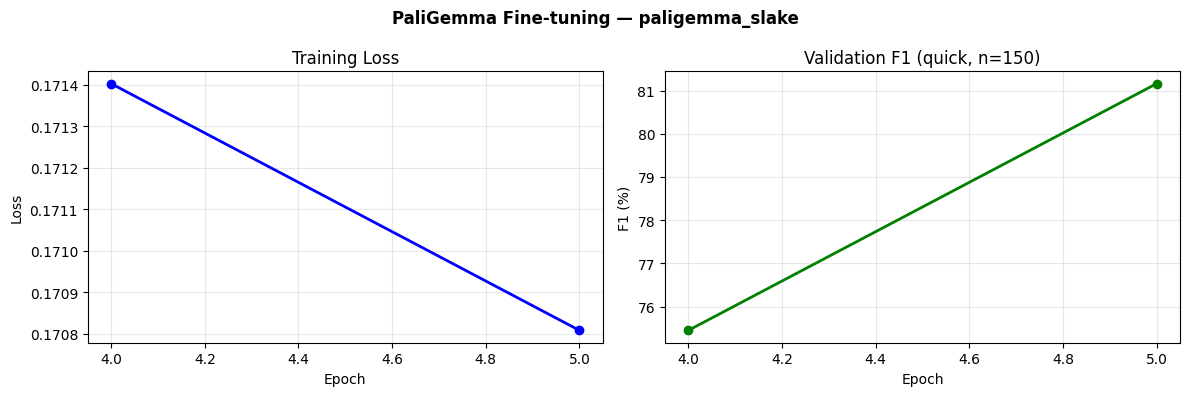

Saved training_curves.png


In [15]:
# Plot training curves
epochs_x = list(range(START_EPOCH + 1, START_EPOCH + NUM_EPOCHS + 1))
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(epochs_x, train_losses, 'b-o', linewidth=2)
ax1.set(xlabel='Epoch', ylabel='Loss', title='Training Loss')
ax1.grid(True, alpha=0.3)
ax2.plot(epochs_x, val_f1s, 'g-o', linewidth=2)
ax2.set(xlabel='Epoch', ylabel='F1 (%)', title='Validation F1 (quick, n=150)')
ax2.grid(True, alpha=0.3)
plt.suptitle(f'PaliGemma Fine-tuning — {EXPERIMENT_NAME}', fontweight='bold')
plt.tight_layout()
plt.savefig('training_curves.png', dpi=150)
plt.show()
print('Saved training_curves.png')

## 🧪 Phần 7: Load & Evaluate / Inference

> Chạy phần này **độc lập** bất cứ lúc nào — không cần chạy lại training

In [16]:
# Load model để evaluate
from transformers import AutoProcessor, PaliGemmaForConditionalGeneration, BitsAndBytesConfig
from peft import PeftModel, prepare_model_for_kbit_training
from huggingface_hub import login

login(token=HF_TOKEN)

# 'best' | 'last' | epoch number (vd: 3)
EVAL_FROM = 'best'   # load checkpoint tốt nhất để evaluate

ckpt_path, ckpt_state = ckpt_mgr.load(EVAL_FROM)

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
    bnb_4bit_quant_type='nf4'
) if USE_4BIT else None

eval_processor = AutoProcessor.from_pretrained(ckpt_path / 'processor')

base = PaliGemmaForConditionalGeneration.from_pretrained(
    ckpt_state.get('base_model', BASE_MODEL),
    quantization_config=bnb_config,
    device_map='auto',
    torch_dtype=torch.bfloat16,
    token=HF_TOKEN
)

if ckpt_state.get('use_lora', True):
    if USE_4BIT:
        base = prepare_model_for_kbit_training(base)
    eval_model = PeftModel.from_pretrained(base, ckpt_path / 'adapter_model')
else:
    eval_model = PaliGemmaForConditionalGeneration.from_pretrained(
        ckpt_path / 'full_model', device_map='auto', torch_dtype=torch.bfloat16
    )

eval_model.eval()
print(f'\n✅ Loaded: {ckpt_path.name}')
print(f'   Best F1 : {ckpt_state.get("best_f1", "?")}')
print(f'   Dataset : {ckpt_state.get("dataset", "?")}')
print(f'   LR      : {ckpt_state.get("hyperparams", {}).get("lr", "?")}')

📂 Loading: /kaggle/working/checkpoints/paligemma_slake/checkpoint_epoch3


Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/603 [00:00<?, ?it/s]


✅ Loaded: checkpoint_epoch3
   Best F1 : 83.13
   Dataset : mdwiratathya/SLAKE-vqa-english
   LR      : 0.0005


In [17]:
# Inference đơn lẻ
def predict(model, processor, image_input, question):
    from PIL import Image
    import requests
    from io import BytesIO
    if isinstance(image_input, str):
        if image_input.startswith('http'):
            img = Image.open(BytesIO(requests.get(image_input).content))
        else:
            img = Image.open(image_input)
    else:
        img = image_input
    img    = img.convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
    prompt = f"<image> {question}\n"
    inp    = processor(images=img, text=prompt, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        out = model.generate(**inp, max_new_tokens=MAX_TARGET_LEN, do_sample=False)
    return processor.decode(
        out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True
    ).strip()

# Test với 5 samples
print('--- Inference samples ---')
for i in range(5):
    s    = raw_ds[TEST_SPLIT][i]
    pred = predict(eval_model, eval_processor, s['image'], s[Q_COL])
    f1   = token_f1(pred, s[A_COL])
    print(f'[{i}] Q: {s[Q_COL]}')
    print(f'     GT: {s[A_COL]} | Pred: {pred} | F1: {f1:.3f}')
    print()

--- Inference samples ---
[0] Q: What modality is used to take this image?
     GT: CT | Pred: CT | F1: 1.000

[1] Q: Which part of the body does this image belong to?
     GT: Chest | Pred: Chest | F1: 1.000

[2] Q: What is the main organ in the image?
     GT: Lung, Spinal Cord | Pred: Lung | F1: 0.500

[3] Q: What is the largest organ in the picture?
     GT: Lung | Pred: Lung | F1: 1.000

[4] Q: Does the picture contain liver?
     GT: No | Pred: No | F1: 1.000



In [18]:
# Full evaluation trên toàn bộ test set
import pandas as pd
import re
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim

# Load cosine sim model
print('📥 Loading sentence transformer...')
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Loaded!')

def cosine_sim(preds, gts):
    pred_emb = sim_model.encode(preds, convert_to_numpy=True)
    gt_emb   = sim_model.encode(gts,   convert_to_numpy=True)
    return [cos_sim([p], [g])[0][0] for p, g in zip(pred_emb, gt_emb)]

smoothie = SmoothingFunction().method1
rouge    = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

eval_model.eval()
preds, gts, qs, q_types = [], [], [], []

with torch.no_grad():
    for item in tqdm(raw_ds[TEST_SPLIT], desc='Full Eval'):
        img    = item['image'].convert('RGB').resize((IMAGE_SIZE, IMAGE_SIZE))
        q      = str(item[Q_COL])
        gt     = str(item[A_COL])
        prompt = f"<image> {q}\n"
        inp    = eval_processor(images=img, text=prompt, return_tensors='pt').to(DEVICE)
        out    = eval_model.generate(**inp, max_new_tokens=MAX_TARGET_LEN, do_sample=False)
        pred   = eval_processor.decode(
            out[0][inp['input_ids'].shape[1]:], skip_special_tokens=True
        ).strip()
        preds.append(pred)
        gts.append(gt)
        qs.append(q)
        q_types.append('CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN')

# Tính metrics
f1s, accs, bleu1s, bleu4s, rougels = [], [], [], [], []
for pred, gt in zip(preds, gts):
    pred_tok = normalize(pred).split()
    gt_tok   = normalize(gt).split()
    f1s.append(token_f1(pred, gt))
    accs.append(int(normalize(pred) == normalize(gt)))
    bleu1s.append(sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie))
    bleu4s.append(sentence_bleu([gt_tok], pred_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie))
    rougels.append(rouge.score(gt, pred)['rougeL'].fmeasure)

print('🔍 Tính Cosine Similarity...')
cosine_scores = cosine_sim(preds, gts)

ci = [i for i, t in enumerate(q_types) if t == 'CLOSED']
oi = [i for i, t in enumerate(q_types) if t == 'OPEN']

def avg(lst, idx=None):
    if idx is None:
        return sum(lst) / len(lst) * 100
    return sum(lst[i] for i in idx) / max(len(idx), 1) * 100

print('\n' + '='*55)
print('📊 PALIGEMMA FULL RESULTS')
print('='*55)
print(f'{"Metric":<20} {"Overall":>10} {"Closed":>10} {"Open":>10}')
print('-'*55)
print(f'{"Exact Match":<20} {avg(accs):>9.2f}% {avg(accs,ci):>9.2f}% {avg(accs,oi):>9.2f}%')
print(f'{"Token F1":<20} {avg(f1s):>9.2f}% {avg(f1s,ci):>9.2f}% {avg(f1s,oi):>9.2f}%')
print(f'{"BLEU-1":<20} {avg(bleu1s):>9.2f}% {avg(bleu1s,ci):>9.2f}% {avg(bleu1s,oi):>9.2f}%')
print(f'{"BLEU-4":<20} {avg(bleu4s):>9.2f}% {avg(bleu4s,ci):>9.2f}% {avg(bleu4s,oi):>9.2f}%')
print(f'{"ROUGE-L":<20} {avg(rougels):>9.2f}% {avg(rougels,ci):>9.2f}% {avg(rougels,oi):>9.2f}%')
print(f'{"Cosine Sim":<20} {avg(cosine_scores):>9.2f}% {avg(cosine_scores,ci):>9.2f}% {avg(cosine_scores,oi):>9.2f}%')
print('='*55)
print(f'  n_total={len(preds)} | n_closed={len(ci)} | n_open={len(oi)}')

# Lưu CSV
df = pd.DataFrame({
    'question':     qs,
    'prediction':   preds,
    'ground_truth': gts,
    'q_type':       q_types,
    'exact_match':  accs,
    'token_f1':     f1s,
    'bleu1':        bleu1s,
    'bleu4':        bleu4s,
    'rouge_l':      rougels,
    'cosine_sim':   cosine_scores
})
out_csv = f'{EXPERIMENT_NAME}_predictions.csv'
df.to_csv(out_csv, index=False)
print(f'\n✅ Saved: {out_csv} ({len(df)} rows)')

📥 Loading sentence transformer...


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

✅ Loaded!


Full Eval:   0%|          | 0/1061 [00:00<?, ?it/s]

🔍 Tính Cosine Similarity...

📊 PALIGEMMA FULL RESULTS
Metric                  Overall     Closed       Open
-------------------------------------------------------
Exact Match              76.91%     85.35%     72.66%
Token F1                 81.23%     85.35%     79.16%
BLEU-1                   80.41%     85.35%     77.92%
BLEU-4                   16.43%     15.18%     17.06%
ROUGE-L                  80.89%     85.35%     78.64%
Cosine Sim               91.32%     96.10%     88.92%
  n_total=1061 | n_closed=355 | n_open=706

✅ Saved: paligemma_slake_predictions.csv (1061 rows)


In [19]:
!pip install rouge-score bert-score nltk -q
import nltk
nltk.download('punkt')
nltk.download('punkt_tab')
print('✅ Xong!')

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.1/61.1 kB 2.4 MB/s eta 0:00:00


[nltk_data] Downloading package punkt to /usr/share/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package punkt_tab to /usr/share/nltk_data...


✅ Xong!


[nltk_data]   Package punkt_tab is already up-to-date!


📥 Loading sentence transformer...


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


✅ Loaded!
--- 5 mẫu ngẫu nhiên ---
[0] Q        : Which part of the body does this image belong to?
      GT       : Abdomen
      Pred     : Chest
      Type     : OPEN
      EM       : ❌
      Token F1 : 0.000
      BLEU-1   : 0.000
      BLEU-4   : 0.000
      ROUGE-L  : 0.000

[1] Q        : Where is/are the abnormality located?
      GT       : Left Lung, Lower Right
      Pred     : Lower Left Lung
      Type     : OPEN
      EM       : ❌
      Token F1 : 0.857
      BLEU-1   : 0.717
      BLEU-4   : 0.191
      ROUGE-L  : 0.571

[2] Q        : What disease is/are shown on the lower left of lung?
      GT       : Pulmonary Infiltration
      Pred     : Pulmonary Mass
      Type     : OPEN
      EM       : ❌
      Token F1 : 0.500
      BLEU-1   : 0.500
      BLEU-4   : 0.150
      ROUGE-L  : 0.500

[3] Q        : What organ system is pictured?
      GT       : Chest
      Pred     : Chest
      Type     : OPEN
      EM       : ✅
      Token F1 : 1.000
      BLEU-1   : 1.000
     

/tmp/ipykernel_22/4146710032.py:91: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22/4146710032.py:91: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_22/4146710032.py:92: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
/tmp/ipykernel_22/4146710032.py:92: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 10060 (\N{CROSS MARK}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.12/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 9989 (\N{WHITE HEAVY CHECK MARK}) missing from font(s) DejaVu Sans.
  fig.c

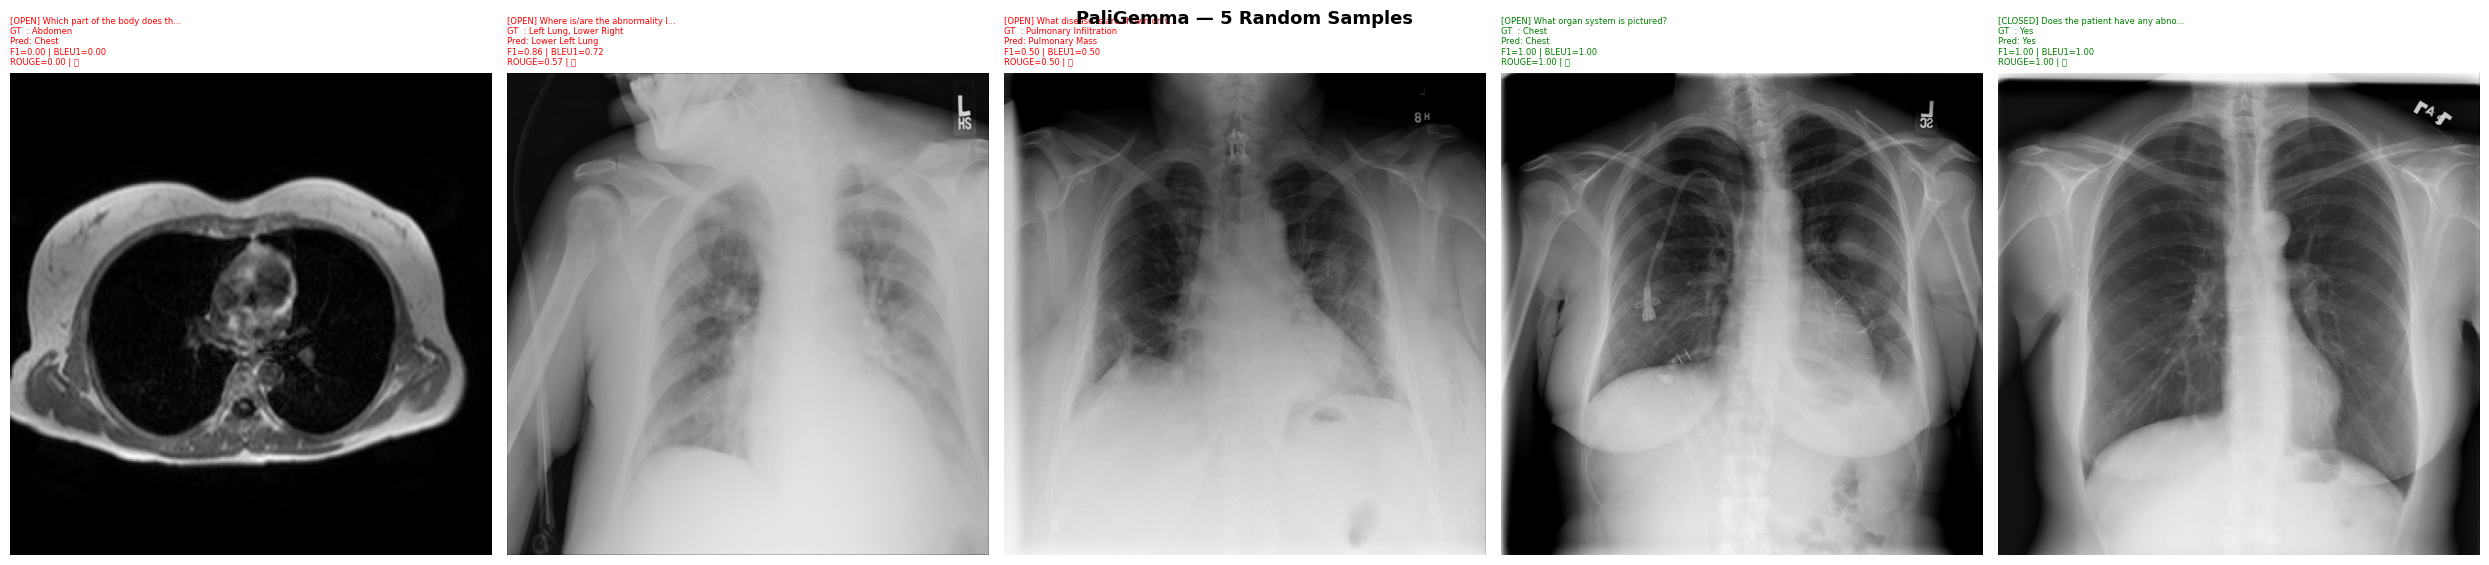


✅ Saved: random_samples.png


In [20]:
import random
import matplotlib.pyplot as plt
import pandas as pd
from nltk.translate.bleu_score import sentence_bleu, SmoothingFunction
from rouge_score import rouge_scorer
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity as cos_sim
import numpy as np

# Load model cosine similarity (~90MB, nhẹ hơn BERTScore nhiều)
print('📥 Loading sentence transformer...')
sim_model = SentenceTransformer('all-MiniLM-L6-v2')
print('✅ Loaded!')

def cosine_sim(preds, gts):
    pred_emb = sim_model.encode(preds, convert_to_numpy=True)
    gt_emb   = sim_model.encode(gts,   convert_to_numpy=True)
    return [cos_sim([p], [g])[0][0] for p, g in zip(pred_emb, gt_emb)]

# ==========================================
# PHẦN 1: 5 mẫu ngẫu nhiên
# ==========================================
random.seed(42)
sample_ids = random.sample(range(len(raw_ds[TEST_SPLIT])), 5)

smoothie = SmoothingFunction().method1
rouge    = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

fig, axes = plt.subplots(1, 5, figsize=(25, 6))
print('--- 5 mẫu ngẫu nhiên ---')

sample_preds, sample_gts = [], []

for idx, sample_id in enumerate(sample_ids):
    item   = raw_ds[TEST_SPLIT][sample_id]
    q      = str(item[Q_COL])
    gt     = str(item[A_COL])
    pred   = predict(eval_model, eval_processor, item['image'], q)
    q_type = 'CLOSED' if gt.lower() in ['yes', 'no'] else 'OPEN'

    # Tính metrics
    pred_tok = normalize(pred).split()
    gt_tok   = normalize(gt).split()
    f1       = token_f1(pred, gt)
    em       = int(normalize(pred) == normalize(gt))
    bleu1    = sentence_bleu([gt_tok], pred_tok, weights=(1,0,0,0), smoothing_function=smoothie)
    bleu4    = sentence_bleu([gt_tok], pred_tok, weights=(0.25,0.25,0.25,0.25), smoothing_function=smoothie)
    rouge_l  = rouge.score(gt, pred)['rougeL'].fmeasure

    sample_preds.append(pred)
    sample_gts.append(gt)

    # Hiển thị ảnh
    ax = axes[idx]
    ax.imshow(item['image'], cmap='gray')
    ax.axis('off')
    color = 'green' if em else 'red'
    for spine in ax.spines.values():
        spine.set_edgecolor(color)
        spine.set_linewidth(4)
        spine.set_visible(True)

    q_short = q[:30] + '...' if len(q) > 30 else q
    ax.set_title(
        f"[{q_type}] {q_short}\n"
        f"GT  : {gt}\n"
        f"Pred: {pred}\n"
        f"F1={f1:.2f} | BLEU1={bleu1:.2f}\n"
        f"ROUGE={rouge_l:.2f} | {'✅' if em else '❌'}",
        fontsize=6, loc='left', color=color
    )

    print(f'[{idx}] Q        : {q}')
    print(f'      GT       : {gt}')
    print(f'      Pred     : {pred}')
    print(f'      Type     : {q_type}')
    print(f'      EM       : {"✅" if em else "❌"}')
    print(f'      Token F1 : {f1:.3f}')
    print(f'      BLEU-1   : {bleu1:.3f}')
    print(f'      BLEU-4   : {bleu4:.3f}')
    print(f'      ROUGE-L  : {rouge_l:.3f}')
    print()

# Cosine Similarity cho 5 mẫu
print('🔍 Tính Cosine Similarity cho 5 mẫu...')
sample_cosine = cosine_sim(sample_preds, sample_gts)
for idx, cs in enumerate(sample_cosine):
    print(f'  [{idx}] Cosine Sim: {cs:.3f}')

plt.suptitle('PaliGemma — 5 Random Samples', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.savefig('random_samples.png', dpi=150, bbox_inches='tight')
plt.show()
print('\n✅ Saved: random_samples.png')
